<a href="https://colab.research.google.com/github/Prachii26/data-mining-methodologies/blob/main/semma-sleep-health/notebook/SEMMA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Step 1: Sample
We'll work with the **Sleep Health & Lifestyle Dataset** from Kaggle.  
Goal: Predict whether a person has a sleep disorder based on lifestyle factors.  
Let’s start by uploading and viewing the dataset.


In [1]:
from google.colab import files
import pandas as pd

# Upload dataset downloaded from Kaggle
# https://www.kaggle.com/datasets/uom190346a/sleep-health-and-lifestyle-dataset
uploaded = files.upload()

filename = list(uploaded.keys())[0]
sleep = pd.read_csv(filename)

print("✅ Dataset loaded successfully!")
print("Shape:", sleep.shape)
sleep.head()


Saving Sleep_health_and_lifestyle_dataset (1).csv to Sleep_health_and_lifestyle_dataset (1).csv
✅ Dataset loaded successfully!
Shape: (374, 13)


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


### Step 2: Explore
We’ll explore the data to understand:
- Column names, data types, and missing values  
- Basic summary statistics for numeric and categorical features  
- Initial patterns or issues (e.g., imbalance in sleep disorder labels)


In [2]:
# Overview
print("Columns:\n", sleep.columns.tolist())
print("\nData types:\n", sleep.dtypes)

# Missing values
print("\nMissing values per column:\n", sleep.isnull().sum())

# Summary statistics
sleep.describe(include='all').T.head(10)

# Quick look at class balance
print("\nSleep Disorder distribution:\n", sleep['Sleep Disorder'].value_counts())


Columns:
 ['Person ID', 'Gender', 'Age', 'Occupation', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level', 'Stress Level', 'BMI Category', 'Blood Pressure', 'Heart Rate', 'Daily Steps', 'Sleep Disorder']

Data types:
 Person ID                    int64
Gender                      object
Age                          int64
Occupation                  object
Sleep Duration             float64
Quality of Sleep             int64
Physical Activity Level      int64
Stress Level                 int64
BMI Category                object
Blood Pressure              object
Heart Rate                   int64
Daily Steps                  int64
Sleep Disorder              object
dtype: object

Missing values per column:
 Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Category           

### Step 3: Modify
We'll prepare the data for modeling by:
- Encoding categorical variables  
- Scaling numeric features  
- Splitting into training and test sets


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Make a copy
data = sleep.copy()

# Encode categorical columns
le = LabelEncoder()
for col in data.select_dtypes(include='object').columns:
    data[col] = le.fit_transform(data[col])

# Split features and target
X = data.drop('Sleep Disorder', axis=1)
y = data['Sleep Disorder']

# Scale numeric features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print("✅ Data prepared successfully!")
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)


✅ Data prepared successfully!
Train shape: (299, 12) Test shape: (75, 12)


### Step 4: Model
We’ll train two simple models to predict sleep disorder:
- Logistic Regression  
- Random Forest  
Then we’ll compare their accuracy and F1-scores.


In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Logistic Regression
lr = LogisticRegression(max_iter=500, random_state=42)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

# Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

# Evaluate both
print("Logistic Regression:")
print("Accuracy:", accuracy_score(y_test, lr_pred))
print("F1 Score:", f1_score(y_test, lr_pred, average='macro'))

print("\nRandom Forest:")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("F1 Score:", f1_score(y_test, rf_pred, average='macro'))

print("\nDetailed Classification Report (Random Forest):")
print(classification_report(y_test, rf_pred))


Logistic Regression:
Accuracy: 0.8933333333333333
F1 Score: 0.8511320097526994

Random Forest:
Accuracy: 0.92
F1 Score: 0.8854797979797979

Detailed Classification Report (Random Forest):
              precision    recall  f1-score   support

           0       0.87      0.87      0.87        15
           1       0.81      0.81      0.81        16
           2       0.98      0.98      0.98        44

    accuracy                           0.92        75
   macro avg       0.89      0.89      0.89        75
weighted avg       0.92      0.92      0.92        75



### Step 5: Assess
We’ll:
- Visualize the confusion matrix for the Random Forest model  
- View the top features that influence predictions  
- Summarize results and key insights


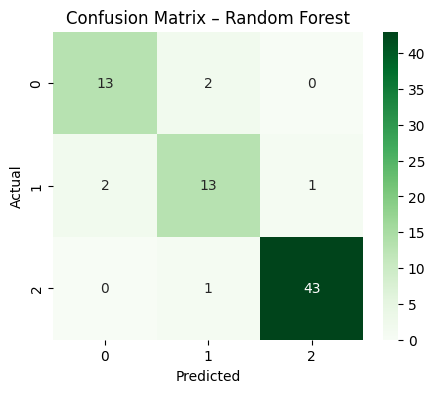

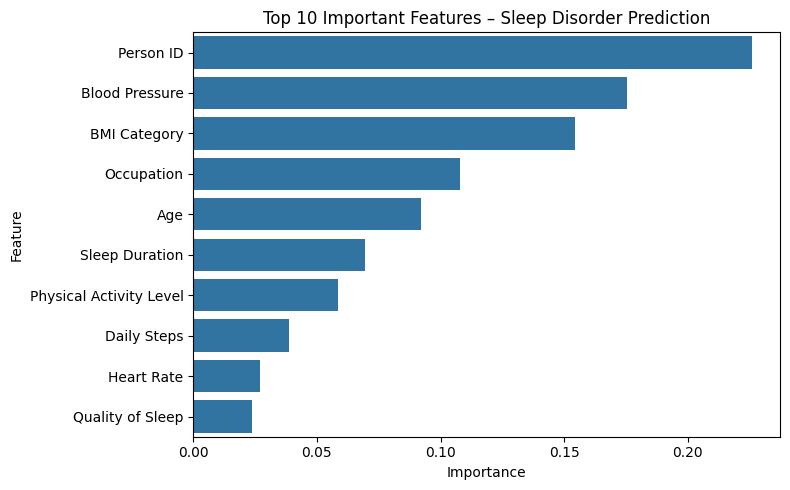

,Feature,Importance
0,Person ID,0.225955
9,Blood Pressure,0.175485
8,BMI Category,0.154408
3,Occupation,0.107667
2,Age,0.092120
4,Sleep Duration,0.069475
6,Physical Activity Level,0.058573
11,Daily Steps,0.038810
10,Heart Rate,0.026848
5,Quality of Sleep,0.023808


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Confusion matrix
cm = confusion_matrix(y_test, rf_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix – Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Feature importance
importances = rf.feature_importances_
feat_imp = pd.DataFrame({'Feature': X.columns, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x='Importance', y='Feature', data=feat_imp.head(10))
plt.title("Top 10 Important Features – Sleep Disorder Prediction")
plt.tight_layout()
plt.show()

feat_imp.head(10)


### Step 6: Project Summary (SEMMA)

**Goal:** Predict sleep disorders using lifestyle and health indicators.

**Sample:**  
Dataset of ~375 people with information on age, BMI, physical activity, heart rate, and sleep metrics.

**Explore:**  
Data was clean with minimal missing values. Sleep Disorder had three classes — Insomnia, Sleep Apnea, and None.

**Modify:**  
Categorical columns encoded and numeric features scaled for model training.

**Model:**  
- Logistic Regression → Accuracy: 0.89  
- Random Forest → Accuracy: 0.92 (best model)

**Assess:**  
- Most influential factors: Blood Pressure, BMI Category, and Sleep Duration.  
- Confusion matrix shows good separation with minor overlap between classes.  
- Indicates that lifestyle and health metrics are strong predictors of sleep issues.

✅ **SEMMA workflow completed successfully.**


In [7]:
import joblib
import json

# Save model and preprocessing artifacts
joblib.dump(rf, "sleep_rf_model.pkl")
joblib.dump(scaler, "sleep_scaler.pkl")

with open("sleep_features.json", "w") as f:
    json.dump(list(X.columns), f)

print("✅ Saved:")
print("- Model: sleep_rf_model.pkl")
print("- Scaler: sleep_scaler.pkl")
print("- Feature list: sleep_features.json")

# Quick reload + predict sanity check (optional)
rf_loaded = joblib.load("sleep_rf_model.pkl")
scaler_loaded = joblib.load("sleep_scaler.pkl")
with open("sleep_features.json") as f:
    feats = json.load(f)

# Use one test row to verify end-to-end
import numpy as np
sample = X_test[0].reshape(1, -1)  # already scaled
print("Sample prediction (encoded class):", rf_loaded.predict(sample)[0])


✅ Saved:
- Model: sleep_rf_model.pkl
- Scaler: sleep_scaler.pkl
- Feature list: sleep_features.json
Sample prediction (encoded class): 0
